# Loading Data and Inspecting the features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/original_placement_data.csv")

In [3]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [4]:
df.shape

(100, 3)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [6]:
df.isnull().sum()

cgpa         5
iq           0
placement    0
dtype: int64

In [7]:
df.duplicated().sum()

0

# Data Cleaning
We have three issues in data. 

1. CGPA is given as "6,8" a string. Not as "6.8" a float
2. There are 5 missing values
3. Placement data is "Yes", "No". We will convert it int 1 and 0

In [8]:
#changing the cgpa string from format "6,8" to "6.8"
df["cgpa"] = df["cgpa"].str.replace(",", ".")
df.head()

,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [10]:
df.describe()

,iq
count,100.000000
mean,123.580000
std,39.944198
min,37.000000
25%,101.500000
50%,127.500000
75%,149.000000
max,233.000000


In [11]:
#converting cgpa from string to float
df["cgpa"] = df["cgpa"].astype(float)
df.head()

,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [13]:
df.describe()

,cgpa,iq
count,95.000000,100.000000
mean,5.988421,123.580000
std,1.157112,39.944198
min,3.300000,37.000000
25%,5.000000,101.500000
50%,6.000000,127.500000
75%,6.900000,149.000000
max,8.500000,233.000000


In [14]:
#filling missing cgpa values with mean
df["cgpa"].fillna(df["cgpa"].mean(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [15]:
df.describe()

,cgpa,iq
count,100.000000,100.000000
mean,5.988421,123.580000
std,1.127513,39.944198
min,3.300000,37.000000
25%,5.075000,101.500000
50%,6.000000,127.500000
75%,6.825000,149.000000
max,8.500000,233.000000


In [16]:
#verifying no missing values
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

In [17]:
#Convert Placement to Binary
df["placement"] = df["placement"].map({"Yes":1, "No":0})
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [19]:
#Save Clean Dataset
df.to_csv("../data/cleaned_placement_data.csv", index=False)


# Exploratory Data Analysis

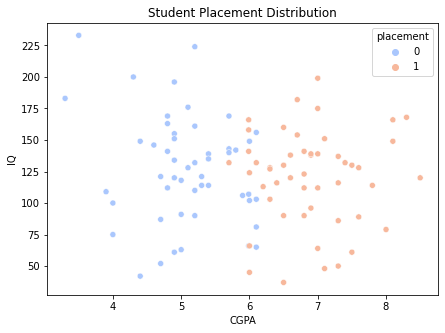

In [20]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="cgpa",
    y="iq",
    hue="placement",
    palette="coolwarm"
)

plt.title("Student Placement Distribution")
plt.xlabel("CGPA")
plt.ylabel("IQ")

plt.show()

1. Do placed students tend to have higher CGPA?

2. Does IQ matter strongly or weakly?

3. Can you visually imagine a line separating the two groups?

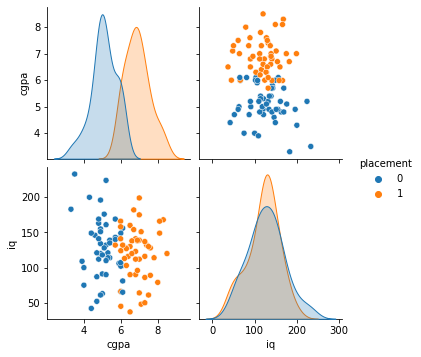

In [21]:
sns.pairplot(df, hue="placement")

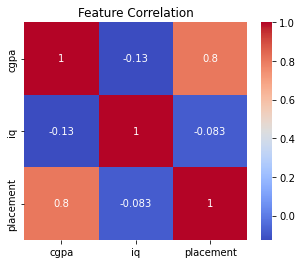

In [22]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

Interpretation:

CGPA is the dominant feature.

CGPA drives the decision boundary

IQ slightly adjusts it

# Prepare Features for Machine Learning

In [23]:
X = df[["cgpa", "iq"]]
y = df["placement"]

In [24]:
X.shape

(100, 2)

In [25]:
y.shape

(100,)

In [26]:
#Splitting data into train and test datsets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)

(90, 2)
(10, 2)


In [28]:
# Scaling features for better learning
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
print(X_train[:5,:])

[[-1.76291775 -0.62029848]
 [ 1.48167735  0.09806189]
 [-0.95176898 -1.62087186]
 [ 0.03963508  0.63683217]
 [ 1.21129442 -0.97947867]]


# Train the Logistic Regression Model


In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [31]:
# Make Predictions
y_pred = model.predict(X_test)
y_pred

array([1, 1, 1, 0, 1, 0, 0, 0, 0, 1], dtype=int64)

In [32]:
# Compare Predictions with True Values
print("Predicted:", y_pred)
print("Actual:", y_test.values)

Predicted: [1 1 1 0 1 0 0 0 0 1]
Actual: [1 1 1 1 1 0 0 0 1 1]


In [33]:
# Calculate Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8


Meaning: 80% of predictions were correct

In [34]:
# Check Model Coefficients
print("Model coefficients:", model.coef_)
print("Model intercept:", model.intercept_)

Model coefficients: [[3.28852839 0.31689204]]
Model intercept: [-0.25426555]


# Visualize the Decision Boundary

In [35]:
#pip install mlxtend

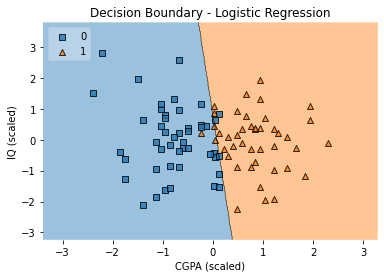

In [36]:
from mlxtend.plotting import plot_decision_regions
import numpy as np

plot_decision_regions(
    X_train,
    y_train.values,
    clf=model,
    legend=2
)

plt.xlabel("CGPA (scaled)")
plt.ylabel("IQ (scaled)")
plt.title("Decision Boundary - Logistic Regression")

plt.show()

In [37]:
# Save the model
import joblib

joblib.dump(model, "../models/model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']